# Fitting a transfer function to the motor log with `tfest`

`output.txt` is the log written by the firmware while a fixed drive pulse is applied to the
motor.  It is comma separated, one row per sample:

| column | contents |
|---|---|
| 0 | timestamp [µs] (uniform 200 µs step → 5 kHz) |
| 1 | position |
| 2 | **speed** |
| 3 | **drive** (pwm / torque command) |
| 4 | current [adc counts] |

This notebook installs [`tfest`](https://pypi.org/project/tfest/), uses the `tfest_fit`
module in this repo to estimate a continuous-time transfer function from that log, and plots
the measured speed against the curve the fitted function produces.

## 1. Install

`tfest` needs numpy, scipy and matplotlib.  A plain `pip install tfest` **fails**: the package's
`setup.py` imports the package itself (which imports matplotlib) while building the wheel, and
pip's isolated build environment has no matplotlib in it.  Installing with
`--no-build-isolation` builds against the current environment instead, which does have it:

In [1]:
!pip install numpy scipy matplotlib
!pip install --no-build-isolation tfest

## 2. Using the `tfest_fit` module

`tfest_fit.py` sits next to this notebook.  One call does everything:

```python
from tfest_fit import fit_transfer_function, plot, DRIVE_COL, SPEED_COL

fit = fit_transfer_function(x_col=DRIVE_COL, y_col=SPEED_COL, n_zeros=0, n_poles=1)
```

Arguments:

| argument | meaning |
|---|---|
| `path` | log file, default `"output.txt"` |
| `x_col`, `y_col` | which columns are the input *u* and the output *y* |
| `n_zeros`, `n_poles` | order of the transfer function to fit |
| `time_col`, `time_unit` | column holding the time base and its unit (µs → s) |
| `method` | `tfest` estimator: `"h1"` (default), `"h2"` or `"fft"` |
| `restarts`, `seed` | `tfest` seeds its optimiser randomly; the best of `restarts` runs is kept, reproducibly |

It returns a `Fit` named tuple:

| field | meaning |
|---|---|
| `fit.tf` | the fitted function, a `scipy.signal.lti` |
| `fit.t` | sample times [s] |
| `fit.u`, `fit.y` | the measured input and output |
| `fit.y_fit` | the computed curve — `fit.tf` replayed on `fit.u` |
| `fit.rmse` | rms error between `y` and `y_fit` |
| `fit.estimator` | the raw `tfest` object, for `.plot()` / `.plot_bode()` |

`plot(fit)` draws measured vs. fitted; `plot(fit, "name.png")` saves it instead.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from tfest_fit import fit_transfer_function, load_data, DRIVE_COL, SPEED_COL, TIME_COL

data = load_data("output.txt")
t = data[:, TIME_COL] * 1e-6          # µs -> s
print("samples:", data.shape[0], " sample interval:", np.diff(data[:, TIME_COL])[0], "us")

samples: 1000  sample interval: 200.0 us


## 3. Which columns to use, and why

A transfer function *H(s) = Y(s)/U(s)* describes how an **input** drives an **output**, so the two
columns have to be a cause/effect pair.

Plotting the log makes the choice obvious: column 3 is a **step of 400 units applied between
80 ms and 160 ms**, and column 2 (speed) rises for exactly as long as that step lasts and decays
once it is removed.  So column 3 is the input *u* and column 2 is the output *y* — the fit is the
motor's **speed step response**.

Column 0 is not a candidate input: it is the timestamp, a monotone ramp that is the time axis of
every other column rather than a signal acting on the motor.  Column 1 (position) is just the
integral of the speed, and column 4 (current) is an intermediate, not the commanded input.

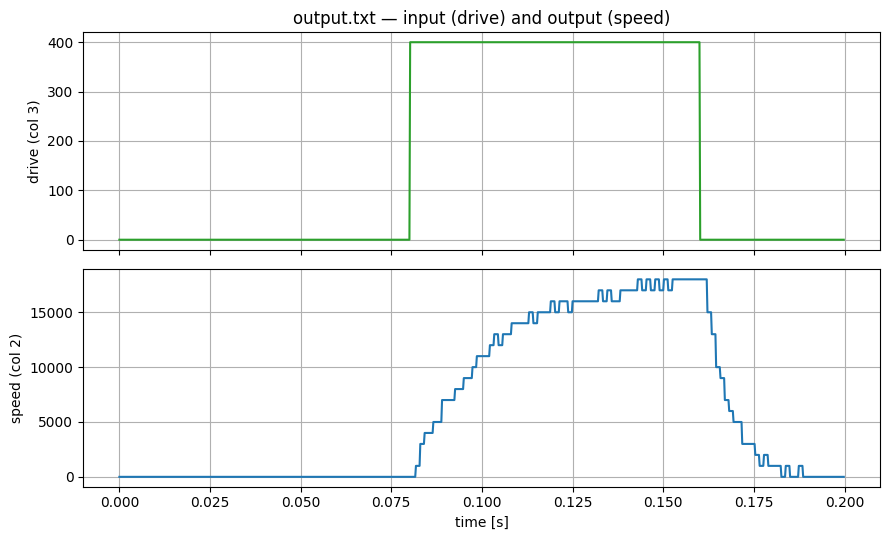

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
ax[0].plot(t, data[:, DRIVE_COL], color="tab:green")
ax[0].set_ylabel("drive (col 3)")
ax[0].set_title("output.txt — input (drive) and output (speed)")
ax[1].plot(t, data[:, SPEED_COL], color="tab:blue")
ax[1].set_ylabel("speed (col 2)")
ax[1].set_xlabel("time [s]")
for a in ax:
    a.grid(True)
plt.tight_layout()
plt.show()

## 4. Fit

The step response climbs smoothly towards a plateau with no overshoot and no oscillation, which
is the signature of a **first order lag**, so `n_zeros=0, n_poles=1`:

$$H(s) = \frac{K}{s + p} = \frac{b_0}{s + a_0}$$

In [4]:
fit = fit_transfer_function(x_col=DRIVE_COL, y_col=SPEED_COL, n_zeros=0, n_poles=1)

num, den = fit.tf.num, fit.tf.den
pole = fit.tf.poles[0].real
dc_gain = num[-1] / den[-1]
tau = -1.0 / pole

print(f"H(s) = {num[0]:.1f} / (s + {den[1]:.2f})")
print(f"pole          : {pole:.2f} rad/s")
print(f"time constant : {tau*1e3:.1f} ms")
print(f"DC gain       : {dc_gain:.1f} speed units per drive unit")
print(f"predicted steady speed at drive=400 : {dc_gain*400:.0f}")
print(f"measured plateau                    : {fit.y.max():.0f}")
print(f"rmse          : {fit.rmse:.0f}")

H(s) = 412.6 / (s + 12.03)
pole          : -12.03 rad/s
time constant : 83.1 ms
DC gain       : 34.3 speed units per drive unit
predicted steady speed at drive=400 : 13721
measured plateau                    : 18000
rmse          : 6081


## 5. Measured vs. fitted

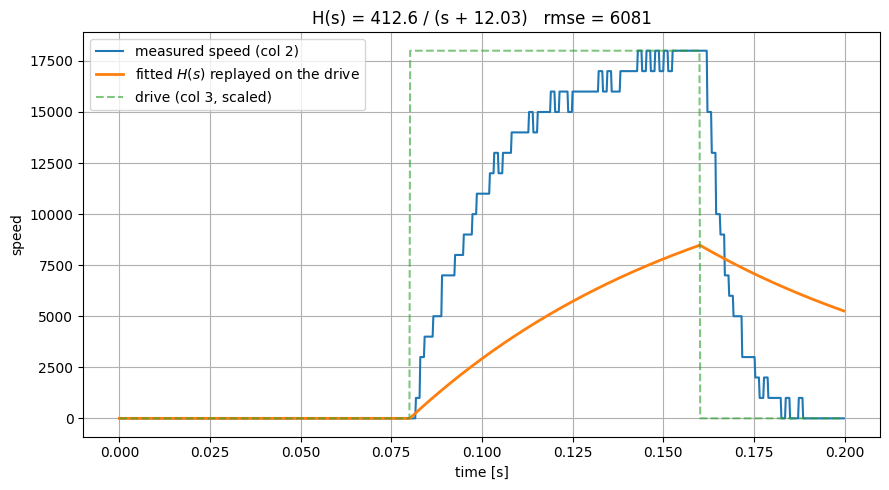

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fit.t, fit.y, label="measured speed (col 2)")
ax.plot(fit.t, fit.y_fit, label="fitted $H(s)$ replayed on the drive", lw=2)
ax.plot(fit.t, fit.u * fit.y.max() / fit.u.max(), "--", color="tab:green", alpha=.6,
        label="drive (col 3, scaled)")
ax.set_xlabel("time [s]")
ax.set_ylabel("speed")
ax.set_title(f"H(s) = {fit.tf.num[0]:.1f} / (s + {fit.tf.den[1]:.2f})   rmse = {fit.rmse:.0f}")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. What the result means

The fit is

$$H(s) \;=\; \frac{413}{s + 12.0}$$

a first order lag, i.e. the continuous-time version of `speed' = -12·speed + 413·drive`:

* **Single real pole at s = −12 rad/s.** Negative, so the motor is stable: left to itself the
  speed decays instead of running away.  The pole sets the **time constant τ = 1/12 ≈ 83 ms** —
  after a change in drive, the speed covers ~63 % of the change in 83 ms and is essentially
  settled after 3τ ≈ 0.25 s.  That is the mechanical/electrical inertia of the joint, and it is
  the number that matters when tuning the PID: the controller cannot usefully be faster than
  what this pole allows.
* **DC gain K/p = 413/12 ≈ 34 speed units per drive unit.** The steady-state speed the motor
  would settle at for a constant drive — 34 × 400 ≈ 13.7 k for this log.
* **No zeros**, so there is no derivative kick: the response to a step starts at zero slope in
  the output and simply rolls towards the plateau.

In short, the identified plant is a plain first order speed system — exactly the `K/(τs+1)`
model that the standard PID tuning rules assume. Whether the two *numbers* can be trusted is
another matter; see the next section.

## 7. Caveat: this fit is mediocre

The plot above shows it plainly — the fitted curve is both **too slow and too low**. Take the
numbers as an order of magnitude, not as an identified model:

* **The measured speed reaches its 18 k plateau about 65 ms after the step**, while the fitted
  τ = 83 ms only gets the model to ~8.5 k by the time the drive is removed. The time-domain
  refit in §8 below puts the real pole at ≈ 81 rad/s (τ ≈ 12 ms), so `tfest`'s pole is nearly
  an order of magnitude too slow.
* **The gain is low too**: the model's asymptotic steady state is 34 × 400 ≈ 13.7 k against a
  measured plateau of 18 k. The resulting rmse, 6081, is about a third of full-scale speed.
* `tfest` does **not** fit the time trace. It forms an H1 estimate of the frequency response
  (`csd(u,y)/psd(u)`) and then runs Nelder–Mead on the polynomial coefficients to match it. The
  time-domain curve above is a *consequence* of that frequency-domain fit, not the objective, so
  nothing forces the two curves to overlap — and nothing constrains the response at ω = 0, which
  is where the gain error comes from.
* The record is a **single pulse**, not a persistently exciting input. One step carries very
  little information at most frequencies, and the speed signal is quantised in steps of 1000, so
  the frequency response being fitted is itself noisy.
* The optimiser starts from a **random guess** and is not global. `restarts=5` (the default)
  keeps the best of five runs; different seeds still move the coefficients around, and higher
  orders (e.g. `n_zeros=1, n_poles=2`) happily return *unstable* poles on this data.

What survives all this is the *structure*: a stable, first order, no-overshoot speed response.
That structure is worth keeping — so the next section keeps it and re-fits the two coefficients
where it actually matters, in the time domain.

## 8. Refitting in the time domain with `least_squares`

`tfest` picked the *structure* — first order, one stable pole, no zero — but matched it against a
frequency response, which is why the time trace does not line up. The fix is to optimise the same
two coefficients against the quantity we actually care about: the measured speed curve.

Write the model monic,

$$H(s) = \frac{b_0}{s + a_0}$$

and let $p = [b_0, a_0]$. For a candidate $p$, `signal.lsim` replays the measured drive through
$H$ and the residual is simply `y_model - y_measured`, one entry per sample.
`scipy.optimize.least_squares` then minimises the sum of squares of that vector — a proper
non-linear least squares in the time domain, started from `tfest`'s answer so it begins in the
right region.

Two practical points:

* an intermediate guess can have a **pole in the right half plane**, which makes `lsim` blow up or
  return `nan`; the residual function catches that and returns a large penalty instead;
* $b_0 \approx 3{\times}10^3$ and $a_0 \approx 10^1$ differ by two orders of magnitude, so
  `x_scale="jac"` lets the optimiser scale the two directions itself.

In [6]:
from scipy import signal
from scipy.optimize import least_squares


def simulate(p, n_zeros, u, t):
    """Replay u through H(s) = p[:n_zeros+1] / (s^n + p[n_zeros+1:]); None if unusable."""
    num, den = p[:n_zeros + 1], np.r_[1.0, p[n_zeros + 1:]]   # monic denominator
    try:
        _, y_model, _ = signal.lsim(signal.lti(num, den), U=u, T=t)
    except Exception:
        return None
    return y_model if np.all(np.isfinite(y_model)) else None


def refit(fit, n_zeros=0):
    """Re-fit a tfest result against the measured time trace."""
    def residual(p):
        y_model = simulate(p, n_zeros, fit.u, fit.t)
        if y_model is None:                    # unstable / non-finite candidate
            return np.full_like(fit.y, 1e6)
        return y_model - fit.y

    p0 = np.r_[fit.tf.num, fit.tf.den[1:]]     # start from tfest's coefficients
    res = least_squares(residual, p0, x_scale="jac")
    num, den = res.x[:n_zeros + 1], np.r_[1.0, res.x[n_zeros + 1:]]
    return signal.lti(num, den), simulate(res.x, n_zeros, fit.u, fit.t), res


tf_ls, y_ls, res = refit(fit)

rmse_ls = float(np.sqrt(np.mean((y_ls - fit.y) ** 2)))
pole_ls = tf_ls.poles[0].real
gain_ls = tf_ls.num[-1] / tf_ls.den[-1]

print(f"least_squares : H(s) = {tf_ls.num[0]:.0f} / (s + {tf_ls.den[1]:.2f})")
print(f"  pole          : {pole_ls:.1f} rad/s   (tfest: {fit.tf.poles[0].real:.1f})")
print(f"  time constant : {-1e3/pole_ls:.1f} ms  (tfest: {-1e3/fit.tf.poles[0].real:.1f} ms)")
print(f"  DC gain       : {gain_ls:.1f}          (tfest: {fit.tf.num[-1]/fit.tf.den[-1]:.1f})")
print(f"  steady speed at drive=400 : {gain_ls*400:.0f}   (measured plateau {fit.y.max():.0f})")
print(f"  rmse          : {rmse_ls:.0f}          (tfest: {fit.rmse:.0f})")
print(f"  {res.nfev} function evaluations, success={res.success}")

least_squares : H(s) = 3236 / (s + 80.83)
  pole          : -80.8 rad/s   (tfest: -12.0)
  time constant : 12.4 ms  (tfest: 83.1 ms)
  DC gain       : 40.0          (tfest: 34.3)
  steady speed at drive=400 : 16012   (measured plateau 18000)
  rmse          : 1264          (tfest: 6081)
  8 function evaluations, success=True


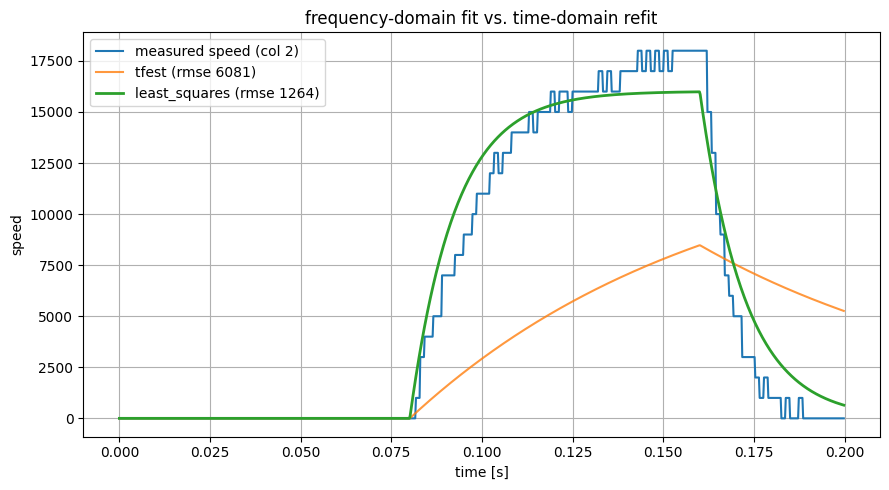

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fit.t, fit.y, label="measured speed (col 2)")
ax.plot(fit.t, fit.y_fit, label=f"tfest (rmse {fit.rmse:.0f})", alpha=.8)
ax.plot(fit.t, y_ls, label=f"least_squares (rmse {rmse_ls:.0f})", lw=2, color="tab:green")
ax.set_xlabel("time [s]")
ax.set_ylabel("speed")
ax.set_title("frequency-domain fit vs. time-domain refit")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### What the refit says

$$H(s) \;=\; \frac{3236}{s + 80.8}$$

* **Pole at −81 rad/s → τ ≈ 12 ms**, not the 83 ms `tfest` reported. The joint accelerates far
  faster than the frequency-domain fit suggested, and this is the number to design the PID around.
* **DC gain 3236/80.8 ≈ 40** speed units per drive unit → ≈ 16 k at drive 400, against a measured
  plateau of 18 k.
* **rmse 1264 instead of 6081** — about 7 % of full-scale speed, a five-fold improvement, and the
  green curve now follows both the rise *and* the decay after the drive is removed.

The remaining gap is honest model error rather than optimiser error: the measured rise is slightly
S-shaped (it starts shallower than a first order lag and keeps creeping up at the top), which hints
at a small transport delay plus a second, slower mechanical mode. A `n_zeros=1, n_poles=2` refit
does reduce the rmse a little further, but on this single pulse it returns an *unstable* pole —
a reminder that the data supports about one pole's worth of information and no more.

So: use `tfest` to pick the model order and get a starting point, and `least_squares` to get
coefficients worth quoting. For a model that is trustworthy across the whole band, log a richer
excitation — a chirp or a PRBS rather than one step — and re-run both.

## 9. Would more poles fit better?

The first order model leaves a visible residual, so the obvious question is whether a richer model
— more poles, maybe a zero — would do better. Two things have to be checked together, because
either one alone is misleading:

* **rmse always improves with more parameters.** It cannot do otherwise: a bigger model contains
  the smaller one. So the comparison needs a penalty for parameter count — `BIC = N·ln(σ²) + k·ln(N)`
  is used below.
* **the fit must stay physical.** Over a finite record an *unstable* model (a pole with a positive
  real part, i.e. in the right half plane) can track a rising signal very convincingly by growing
  exponentially inside the window — and then diverge the moment it is simulated any longer. A
  motor that spins up on its own is not a model of this joint, however low its rmse.

So: sweep the orders, refit each one in the time domain exactly as in §8, and record rmse, BIC
*and* whether every pole ended up in the left half plane.

In [8]:
import warnings
from scipy.signal import BadCoefficients


def simulate(p, n_zeros, u, t):
    """Replay u through H(s) = p[:n_zeros+1] / (s^n + p[n_zeros+1:]); None if unusable."""
    num, den = p[:n_zeros + 1], np.r_[1.0, p[n_zeros + 1:]]
    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore", BadCoefficients)
        try:
            _, y_model, _ = signal.lsim(signal.lti(num, den), U=u, T=t)
        except Exception:
            return None
    return y_model if np.all(np.isfinite(y_model)) else None


def sweep_orders(fit, orders, n_starts=4, seed=0):
    """Time-domain refit at each (n_zeros, n_poles); best of n_starts random starts."""
    rng = np.random.default_rng(seed)
    N = len(fit.y)
    rows = []
    for n_zeros, n_poles in orders:
        best = None
        for _ in range(n_starts):
            num0 = np.r_[np.zeros(n_zeros), 3236.0] * rng.lognormal(0, 0.3, n_zeros + 1)
            den0 = np.poly(-np.abs(rng.lognormal(np.log(80), 0.8, n_poles)))[1:]
            res = least_squares(
                lambda p: (lambda q: q - fit.y if q is not None else np.full_like(fit.y, 1e6))(
                    simulate(p, n_zeros, fit.u, fit.t)),
                np.r_[num0, den0], x_scale="jac", max_nfev=300)
            y_model = simulate(res.x, n_zeros, fit.u, fit.t)
            if y_model is None:
                continue
            rmse = float(np.sqrt(np.mean((y_model - fit.y) ** 2)))
            if best is None or rmse < best["rmse"]:
                tf = signal.lti(res.x[:n_zeros + 1], np.r_[1.0, res.x[n_zeros + 1:]])
                k = len(res.x)
                best = dict(order=f"{n_zeros}z/{n_poles}p", n_zeros=n_zeros, params=k, tf=tf,
                            rmse=rmse, bic=N * np.log(rmse ** 2) + k * np.log(N),
                            y=y_model, stable=bool(np.all(tf.poles.real < 0)))
        if best is not None:
            rows.append(best)
    return rows


orders = [(z, p) for p in range(1, 5) for z in range(p)]
rows = sweep_orders(fit, orders)          # ~1 minute

print(f"{'order':>6} {'params':>7} {'rmse':>8} {'BIC':>9} {'stable':>7}   poles")
for r in rows:
    poles = ", ".join(f"{c.real:.0f}{c.imag:+.0f}j" if c.imag else f"{c.real:.0f}" for c in r["tf"].poles)
    print(f"{r['order']:>6} {r['params']:>7} {r['rmse']:8.0f} {r['bic']:9.0f} "
          f"{'yes' if r['stable'] else 'NO':>7}   {poles}")

 order  params     rmse       BIC  stable   poles
 0z/1p       2     1264     14298     yes   -81
 0z/2p       3     1209     14216     yes   -575, -96
 1z/2p       4     1092     14019      NO   -52, 1
 0z/3p       4     1203     14213     yes   -466+689j, -466-689j, -92
 1z/3p       5     1085     14013      NO   -1846, -59, 6
 2z/3p       6      713     13182      NO   23+81j, 23-81j, -65
 0z/4p       5     1200     14215     yes   -211+1230j, -211-1230j, -775, -94
 1z/4p       6     1066     13986      NO   -149+736j, -149-736j, -58, 5
 2z/4p       7      679     13090      NO   -846, -78, 17+82j, 17-82j
 3z/4p       8      567     12737      NO   33+141j, 33-141j, -38, 26


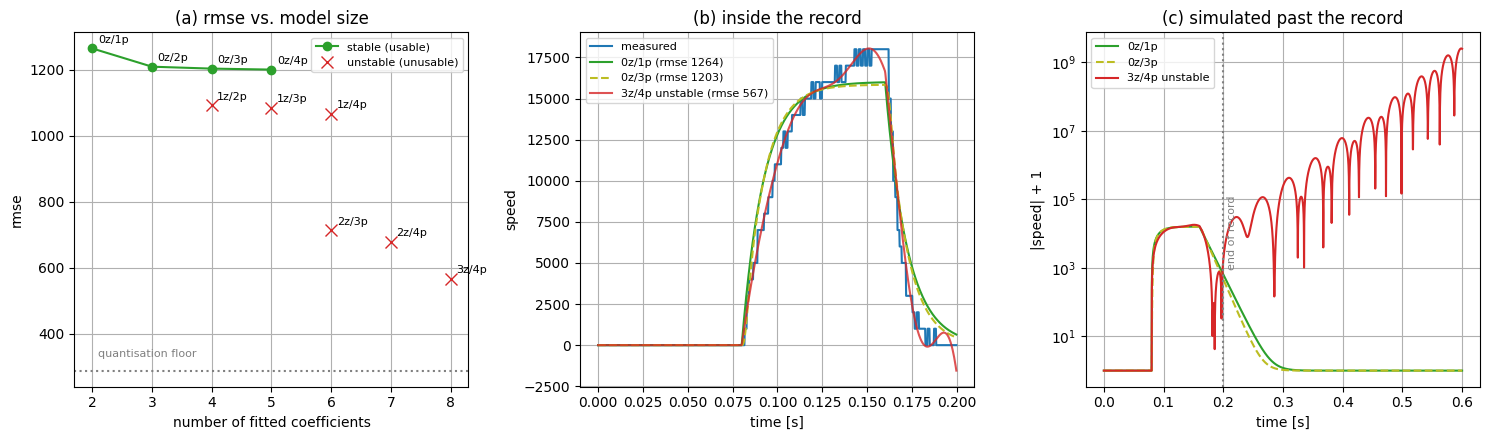

In [9]:
stable = [r for r in rows if r["stable"]]
unstable = [r for r in rows if not r["stable"]]
best_stable = min(stable, key=lambda r: r["bic"])
best_unstable = min(unstable, key=lambda r: r["rmse"])
first_order = rows[0]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) does rmse buy anything?
ax[0].plot([r["params"] for r in stable], [r["rmse"] for r in stable], "o-",
           color="tab:green", label="stable (usable)")
ax[0].plot([r["params"] for r in unstable], [r["rmse"] for r in unstable], "x",
           color="tab:red", ls="none", ms=9, label="unstable (unusable)")
for r in rows:
    ax[0].annotate(r["order"], (r["params"], r["rmse"]), fontsize=8,
                   textcoords="offset points", xytext=(4, 4))
ax[0].axhline(1000 / np.sqrt(12), ls=":", color="grey")
ax[0].text(2.1, 1000 / np.sqrt(12) + 40, "quantisation floor", fontsize=8, color="grey")
ax[0].set_xlabel("number of fitted coefficients")
ax[0].set_ylabel("rmse")
ax[0].set_title("(a) rmse vs. model size")
ax[0].legend(fontsize=8)
ax[0].grid(True)

# (b) what the extra poles actually change in the fit
ax[1].plot(fit.t, fit.y, label="measured", color="tab:blue")
ax[1].plot(fit.t, first_order["y"], label=f"{first_order['order']} (rmse {first_order['rmse']:.0f})",
           color="tab:green")
ax[1].plot(fit.t, best_stable["y"], "--", color="tab:olive",
           label=f"{best_stable['order']} (rmse {best_stable['rmse']:.0f})")
ax[1].plot(fit.t, best_unstable["y"], color="tab:red", alpha=.8,
           label=f"{best_unstable['order']} unstable (rmse {best_unstable['rmse']:.0f})")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("speed")
ax[1].set_title("(b) inside the record")
ax[1].legend(fontsize=8)
ax[1].grid(True)

# (c) the same models simulated past the end of the record
dt = fit.t[1] - fit.t[0]
t_long = np.arange(0, 0.6, dt)
u_long = np.interp(t_long, fit.t, fit.u, right=0.0)
ax[2].semilogy(t_long, np.abs(simulate(np.r_[first_order["tf"].num, first_order["tf"].den[1:]],
                                       first_order["n_zeros"], u_long, t_long)) + 1,
               color="tab:green", label=first_order["order"])
ax[2].semilogy(t_long, np.abs(simulate(np.r_[best_stable["tf"].num, best_stable["tf"].den[1:]],
                                       best_stable["n_zeros"], u_long, t_long)) + 1,
               "--", color="tab:olive", label=best_stable["order"])
ax[2].semilogy(t_long, np.abs(simulate(np.r_[best_unstable["tf"].num, best_unstable["tf"].den[1:]],
                                       best_unstable["n_zeros"], u_long, t_long)) + 1,
               color="tab:red", label=f"{best_unstable['order']} unstable")
ax[2].axvline(fit.t[-1], color="grey", ls=":")
ax[2].text(fit.t[-1] * 1.03, 1e3, "end of record", fontsize=8, color="grey", rotation=90)
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("|speed| + 1")
ax[2].set_title("(c) simulated past the record")
ax[2].legend(fontsize=8)
ax[2].grid(True)

plt.tight_layout()
plt.show()

### Cross-check: a dead time instead of extra poles

The extra poles the sweep picked were all very fast, which is what an optimiser reaches for when the
onset of the response is *late* rather than *slower* — the rational-model way of approximating a
delay. If that is really what is going on, one dead-time parameter should buy the same improvement
as three extra rational coefficients:

In [10]:
def simulate_delayed(p, u, t):
    """First order plus pure dead time: H(s) = b/(s+a) * exp(-s*d)."""
    b, a, d = p
    if a <= 0:
        return None
    y_model = simulate(np.r_[b, a], 0, u, t)
    return None if y_model is None else np.interp(t - d, t, y_model, left=0.0)


best = None
for d0 in (0.0, 0.003, 0.008):                       # a few starting guesses for the delay
    res_d = least_squares(
        lambda p: (lambda q: q - fit.y if q is not None else np.full_like(fit.y, 1e6))(
            simulate_delayed(p, fit.u, fit.t)),
        np.r_[tf_ls.num[0], tf_ls.den[1], d0], x_scale="jac", max_nfev=200)
    y_d = simulate_delayed(res_d.x, fit.u, fit.t)
    rmse_d = float(np.sqrt(np.mean((y_d - fit.y) ** 2)))
    if best is None or rmse_d < best[0]:
        best = (rmse_d, res_d.x, y_d)

rmse_d, (b_d, a_d, delay), y_d = best
best_stable_rows = [r for r in rows if r["stable"]]
print(f"first order + dead time : H(s) = {b_d:.0f}/(s + {a_d:.1f}) * exp(-{delay*1e3:.1f} ms)")
print(f"  tau {1e3/a_d:.1f} ms, DC gain {b_d/a_d:.1f}")
print(f"  rmse {rmse_d:.0f} with 3 coefficients")
print(f"  vs   {rows[0]['rmse']:.0f} for {rows[0]['order']} (2 coefficients)")
for r in best_stable_rows[1:]:
    print(f"  vs   {r['rmse']:.0f} for {r['order']} ({r['params']} coefficients, stable)")
print(f"  quantisation floor 1000/sqrt(12) = {1000/np.sqrt(12):.0f}")

first order + dead time : H(s) = 3730/(s + 94.3) * exp(-1.6 ms)
  tau 10.6 ms, DC gain 39.6
  rmse 1200 with 3 coefficients
  vs   1264 for 0z/1p (2 coefficients)
  vs   1209 for 0z/2p (3 coefficients, stable)
  vs   1203 for 0z/3p (4 coefficients, stable)
  vs   1200 for 0z/4p (5 coefficients, stable)
  quantisation floor 1000/sqrt(12) = 289


### Conclusion: no, not on this data

Panel (a) tells the story. Among the **stable** models the rmse curve is flat: 1264 for the first
order fit, ~1200 for two, three or four poles — a 5 % improvement for two to three extra
coefficients, and BIC is essentially unchanged across them. The extra poles that get added are
very fast ones (−575, −775, −465 ± 689j rad/s, i.e. time constants of 1–2 ms); they only round off
the first two samples of the step, which is exactly where the speed signal is quantisation noise
anyway. Panel (b) shows the best stable higher-order curve (0z/3p, picked by BIC) sitting almost on
top of the first order one — the two are hard to tell apart.

Every model that fits *substantially* better — 713, 679, 567 — has a pole in the **right half
plane**, and BIC happily rewards them because BIC knows nothing about physics. Panel (c) is the
reason they must be rejected: simulated a little past the end of the record, with the drive already
switched off, they run away exponentially. They are not describing the motor, they are describing
one 200 ms window of it.

What the residual actually consists of is therefore not missing poles:

* the speed is **quantised in steps of 1000**, an rms of 1000/√12 ≈ 289 on its own (the dotted line
  in panel (a)) — no model of any order can go below that;
* the measured rise is slightly **S-shaped** at its onset — the cross-check above shows that a
  1.6 ms **dead time** (`e^{-sT}`, not a rational pole) buys exactly the same rmse ≈ 1200 as the
  best stable multi-pole models, with one extra parameter instead of three; so what little
  structure is left is a delay, not missing poles — and it is still only that same 5 %;
* and a **single step** simply does not excite enough frequencies to identify more than about one
  pole, which is why the higher-order fits fall into non-physical solutions instead of refining the
  physical one.

So the first order model stands: $H(s) = 3236/(s + 80.8)$. To do better, the data has to improve
before the model does — log a chirp or a PRBS excitation, and finer speed resolution — and if the
S-shaped onset still shows up, add a dead time rather than another pole.

## 10. The other plant: current → speed

Everything so far models **drive → speed**, because that is what this record actually contains: the
firmware forces the PWM open loop (`motor_measure()` in `main/motor_pid.c` sets
`pwm_speedvalue = 400` at sample 400 and back to `0` at sample 800) while all three PID loops —
torque, velocity and position — are commented out. The log's own print statement fixes the column
mapping beyond doubt:

```c
printf("%d,%d,%d,%d,%f\n", time_array[x], position_array[x],
       velocity_array[x], target_pwm_array[x], torque_array[x]);
```

so column 3 is the *commanded* PWM and column 4 is `torque_measured = last_adc`, the measured motor
current.

There is still a reason to fit **current → speed**: `motor_pid.c` is written as a cascade —
position → velocity → torque → PWM, with `pid_torque` driving the PWM and `pid_velocity` producing a
`target_torque`. Once the torque loop is closed, the velocity PID no longer sees the PWM plant; it
sees torque-request → speed, i.e. the mechanical system alone. That is the model this section
estimates. It is also, as it turns out, what the MATLAB fit

$$H_\text{MATLAB}(s) = \frac{2221\,s + 1.669\cdot10^5}{s^2 + 247.7\,s + 1.28\cdot10^4}$$

appears to be — the comparison below tests that.

**Caveat, and it is not a small one.** In *this* record the current was never commanded. It is a
response to the same PWM step that produced the speed, and the two are coupled in both directions:
current produces torque which accelerates the motor, and the motor's back-EMF feeds back into the
current. Fitting one response from the other is a closed-loop identification, and the estimate is
biased unless that feedback is accounted for. The numbers below are indicative, not clean. The clean
experiment is to uncomment `pid_torque`, step `target_torque` instead of `pwm_speedvalue`, and log
that.

In [11]:
from tfest_fit import CURRENT_COL

current = data[:, CURRENT_COL]


def fit_stable(u, y, t, n_zeros, n_poles, n_starts=6, seed=0):
    """Time-domain fit with the poles forced into the left half plane: den = poly(-exp(theta))."""
    rng = np.random.default_rng(seed)

    def build(p):
        k, zeros, theta = p[0], p[1:1 + n_zeros], p[1 + n_zeros:]
        num = k * np.poly(zeros) if n_zeros else np.array([k])
        return signal.lti(num, np.poly(-np.exp(theta)))

    def sim(p):
        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore", BadCoefficients)
            try:
                _, y_model, _ = signal.lsim(build(p), U=u, T=t)
            except Exception:
                return None
        return y_model if np.all(np.isfinite(y_model)) else None

    best = None
    for _ in range(n_starts):
        p0 = np.r_[rng.lognormal(np.log(2000), .5),
                   -np.abs(rng.lognormal(np.log(100), .6, n_zeros)),
                   rng.normal(np.log(100), .6, n_poles)]
        res = least_squares(
            lambda p: (lambda q: q - y if q is not None else np.full_like(y, 1e6))(sim(p)),
            p0, x_scale="jac", max_nfev=400)
        y_model = sim(res.x)
        if y_model is None:
            continue
        rmse = float(np.sqrt(np.mean((y_model - y) ** 2)))
        if best is None or rmse < best[0]:
            best = (rmse, build(res.x), y_model)
    return best


rmse_i1, tf_i1, y_i1 = fit_stable(current, fit.y, fit.t, 0, 1)   # first order
rmse_i2, tf_i2, y_i2 = fit_stable(current, fit.y, fit.t, 1, 2)   # same structure as the MATLAB fit

tf_matlab = signal.lti([2221.0, 1.669e5], [1.0, 247.7, 1.28e4])
y_m_current = simulate(np.r_[tf_matlab.num, tf_matlab.den[1:]], 1, current, fit.t)
y_m_drive = simulate(np.r_[tf_matlab.num, tf_matlab.den[1:]], 1, fit.u, fit.t)

def describe(name, tf, rmse):
    z = ", ".join(f"{c.real:.1f}" for c in tf.zeros) or "-"
    p_ = ", ".join(f"{c.real:.1f}" for c in tf.poles)
    print(f"{name:28s} {tf.num[-1]/tf.den[-1]:8.2f} {z:>12s} {p_:>18s} {rmse:8.0f}")

print(f"{'model':28s} {'DC gain':>8s} {'zeros':>12s} {'poles':>18s} {'rmse':>8s}")
describe("ours, current -> speed 0z/1p", tf_i1, rmse_i1)
describe("ours, current -> speed 1z/2p", tf_i2, rmse_i2)
describe("MATLAB, replayed on current", tf_matlab, float(np.sqrt(np.mean((y_m_current - fit.y) ** 2))))
describe("MATLAB, replayed on drive", tf_matlab, float(np.sqrt(np.mean((y_m_drive - fit.y) ** 2))))
describe("ours, drive -> speed (§8)", tf_ls, rmse_ls)

print(f"\nMATLAB factored: {tf_matlab.num[0]:.0f}(s + {-tf_matlab.zeros[0].real:.1f}) / "
      f"((s + {-tf_matlab.poles[1].real:.1f})(s + {-tf_matlab.poles[0].real:.1f}))")
print(f"  the zero at -{-tf_matlab.zeros[0].real:.1f} nearly cancels the pole at "
      f"-{-tf_matlab.poles[1].real:.1f}  ->  effectively {tf_matlab.num[0]:.0f}/(s + "
      f"{-tf_matlab.poles[0].real:.1f}), tau {-1e3/tf_matlab.poles[0].real:.1f} ms")
print(f"peak of the measured speed {fit.y.max():.0f}; MATLAB driven by current {y_m_current.max():.0f}, "
      f"by drive {y_m_drive.max():.0f}")

model                         DC gain        zeros              poles     rmse
ours, current -> speed 0z/1p    14.08            -              -57.4     2231
ours, current -> speed 1z/2p    13.96       -133.9       -81.5, -81.5     2214
MATLAB, replayed on current     13.04        -75.1      -174.2, -73.5     3464
MATLAB, replayed on drive       13.04        -75.1      -174.2, -73.5     6348
ours, drive -> speed (§8)       40.03            -              -80.8     1264

MATLAB factored: 2221(s + 75.1) / ((s + 73.5)(s + 174.2))
  the zero at -75.1 nearly cancels the pole at -73.5  ->  effectively 2221/(s + 174.2), tau 5.7 ms
peak of the measured speed 18000; MATLAB driven by current 18096, by drive 5215


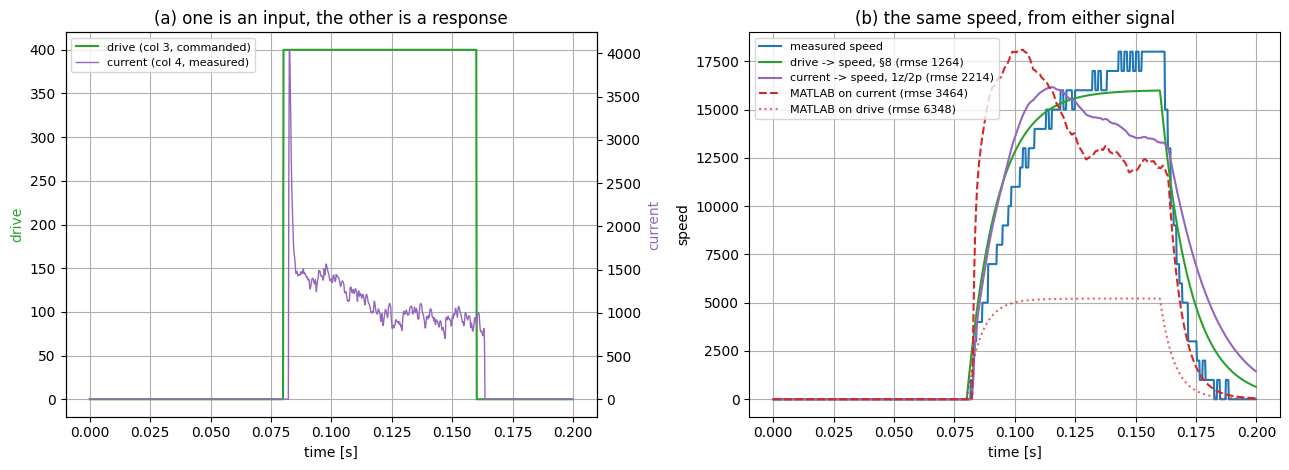

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) the drive is commanded, the current is a response
ax[0].plot(fit.t, fit.u, color="tab:green", label="drive (col 3, commanded)")
ax[0].set_xlabel("time [s]")
ax[0].set_ylabel("drive", color="tab:green")
ax2 = ax[0].twinx()
ax2.plot(fit.t, current, color="tab:purple", lw=1, label="current (col 4, measured)")
ax2.set_ylabel("current", color="tab:purple")
ax[0].set_title("(a) one is an input, the other is a response")
ax[0].grid(True)
lines = ax[0].get_lines() + ax2.get_lines()
ax[0].legend(lines, [l.get_label() for l in lines], fontsize=8, loc="upper left")

# (b) the speed, explained from either signal
ax[1].plot(fit.t, fit.y, label="measured speed", color="tab:blue")
ax[1].plot(fit.t, y_ls, color="tab:green",
           label=f"drive -> speed, §8 (rmse {rmse_ls:.0f})")
ax[1].plot(fit.t, y_i2, color="tab:purple",
           label=f"current -> speed, 1z/2p (rmse {rmse_i2:.0f})")
ax[1].plot(fit.t, y_m_current, "--", color="tab:red",
           label=f"MATLAB on current (rmse {np.sqrt(np.mean((y_m_current-fit.y)**2)):.0f})")
ax[1].plot(fit.t, y_m_drive, ":", color="tab:red", alpha=.7,
           label=f"MATLAB on drive (rmse {np.sqrt(np.mean((y_m_drive-fit.y)**2)):.0f})")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("speed")
ax[1].set_title("(b) the same speed, from either signal")
ax[1].legend(fontsize=8)
ax[1].grid(True)

plt.tight_layout()
plt.show()

### What this says about the MATLAB fit

Fitting current → speed independently here lands on a **DC gain of 14.0** (first order) or **14.0**
(one zero, two poles). The MATLAB model's DC gain is **13.0**. Against the drive the same quantity is
**40** — three times away. A 7 % difference versus a 3× difference is not ambiguous: the MATLAB fit
is a **current → speed** model, and panel (b) shows it directly — driven by the current it peaks at
18096 against a measured 18000, driven by the drive it reaches 5215.

Two further things fall into place:

* **Its second order is spurious.** The zero at −75.2 sits almost on top of the pole at −73.5, and
  the pair cancels: the slow mode carries under 2 % of the step response, leaving
  ≈ 2221/(s + 174) — one pole. Our own 1z/2p fit of the same pair does the same thing differently
  (a repeated pole at −81.5 with a zero at −134) and improves the rmse over first order by 17 out of
  2231. Exactly the §9 result again: this data supports one pole.
* **Neither current model beats the drive model.** rmse 2214 and 3464 against 1264 for
  drive → speed. That is the back-EMF feedback warned about above, plus the fact that the current
  trace is itself noisy and decaying rather than a clean step.

### Which model to use

| purpose | plant | model |
|---|---|---|
| tune a PID whose output is the PWM duty (the loop as logged) | drive → speed | $3236/(s + 80.8)$, τ ≈ 12 ms |
| tune the **velocity** loop of the cascade, once `pid_torque` is closed | torque/current → speed | ≈ $810/(s + 57.4)$, τ ≈ 17 ms, DC gain 14 |

The second row is the one to re-measure rather than trust: uncomment `pid_torque` in
`main/motor_pid.c`, step `target_torque` instead of `pwm_speedvalue`, and log that run. Then the
input is commanded again, the back-EMF path is inside the closed torque loop where it belongs, and
the same `fit_transfer_function` + `least_squares` pipeline applies unchanged — with
`x_col=CURRENT_COL` replaced by the logged torque *request*.

While you are changing the firmware, two cheap improvements to the data itself: the encoder is read
only every 6th tick (`torque_loop_cntr >= 5`) and `velocity_measured = cur_pulse_cntr * 1000`, which
is where both the 1000-unit quantisation and the ~1.2 ms hold in the speed signal come from — and the
1.6 ms dead time of §9 is very close to that hold, i.e. a measurement artefact rather than motor
dynamics. Reading the encoder every tick, or timing the pulses instead of counting them, would lower
the noise floor of every fit in this notebook.

## 11. The MATLAB model on its own, against `output2.txt`

One chart, nothing fitted here: the speed logged in `output2.txt` with the MATLAB transfer function

$$H_\text{MATLAB}(s) = \frac{2221\,s + 1.669\cdot10^5}{s^2 + 247.7\,s + 1.28\cdot10^4}$$

replayed through it. Because the model's input is ambiguous from the coefficients alone, it is drawn
driven by both candidate columns — the commanded drive and the measured current.

output2.txt identical to output.txt: True


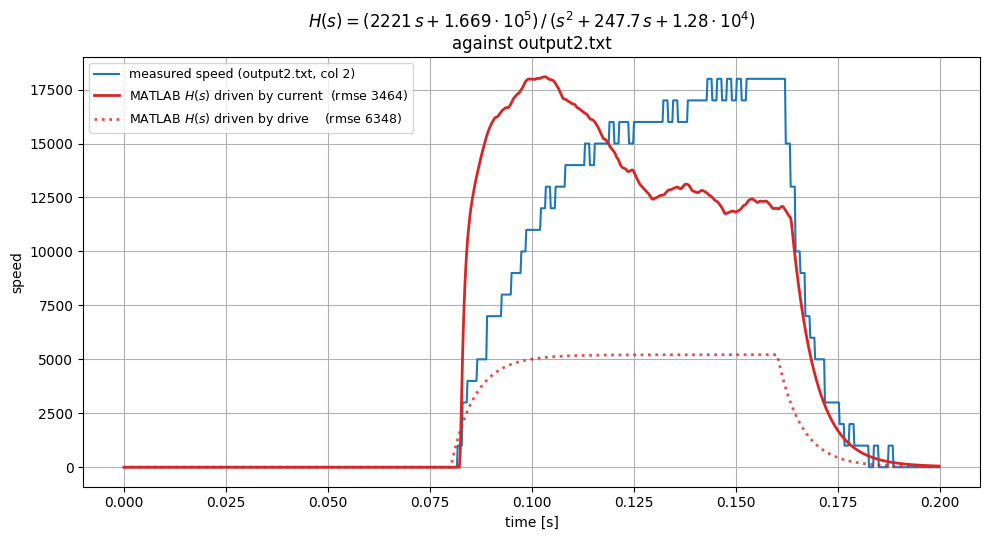

measured plateau         18000
  model on current peak  18096
  model on drive   peak   5215


In [13]:
data2 = load_data("output2.txt")
print("output2.txt identical to output.txt:", np.array_equal(data2, data))

t2 = data2[:, TIME_COL] * 1e-6
speed2 = data2[:, SPEED_COL]
drive2 = data2[:, DRIVE_COL]
current2 = data2[:, CURRENT_COL]

p_matlab = np.r_[tf_matlab.num, tf_matlab.den[1:]]
y2_current = simulate(p_matlab, 1, current2, t2)
y2_drive = simulate(p_matlab, 1, drive2, t2)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(t2, speed2, color="tab:blue", lw=1.5, label="measured speed (output2.txt, col 2)")
ax.plot(t2, y2_current, color="tab:red", lw=2,
        label=f"MATLAB $H(s)$ driven by current  (rmse {np.sqrt(np.mean((y2_current-speed2)**2)):.0f})")
ax.plot(t2, y2_drive, ":", color="tab:red", lw=2, alpha=.8,
        label=f"MATLAB $H(s)$ driven by drive    (rmse {np.sqrt(np.mean((y2_drive-speed2)**2)):.0f})")
ax.set_xlabel("time [s]")
ax.set_ylabel("speed")
ax.set_title(r"$H(s) = (2221\,s + 1.669\cdot 10^5)\,/\,(s^2 + 247.7\,s + 1.28\cdot 10^4)$"
             "\nagainst output2.txt")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"measured plateau        {speed2.max():6.0f}")
print(f"  model on current peak {y2_current.max():6.0f}")
print(f"  model on drive   peak {y2_drive.max():6.0f}")